# Создание маски и аугментаций для выбранного изображения
В этом ноутбуке мы загрузим изображение, построим бинарную маску и подготовим несколько аугментаций для пары «изображение + маска».

## Шаги
1. Указать путь к исходному изображению.\n2. Определить координаты полигона для маски.\n3. Выполнить аугментации и визуализировать результат.

In [433]:
# Опционально: раскомментируйте строку ниже, если требуется доустановить библиотеки
# !pip install opencv-python matplotlib albumentations scikit-image --quiet

In [434]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import hashlib
from pathlib import Path
from albumentations import (
    Compose,
    HorizontalFlip,
    VerticalFlip,
    RandomRotate90,
    RandomBrightnessContrast,
    ShiftScaleRotate,
    OneOf,
    Blur,
    GaussNoise,
    HueSaturationValue,
    RGBShift
)

In [435]:
image_path = Path("./input.jpeg")  
output_dir = Path("./output")
output_dir.mkdir(parents=True, exist_ok=True)

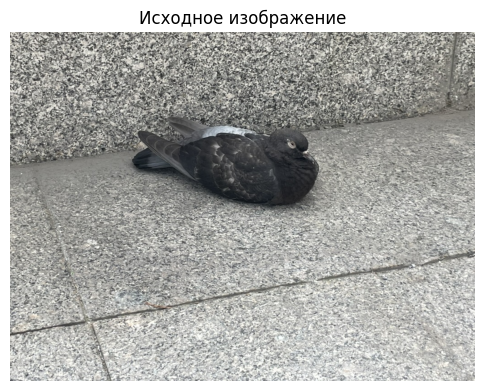

In [436]:
if not image_path.exists():
    raise FileNotFoundError(f"Не удалось найти файл: {image_path}")
image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Исходное изображение")
plt.show()

## Создание маски
Для примера построим маску с помощью пороговой сегментации. При необходимости подберите значение порога под своё изображение или примените дополнительные фильтры перед порогом.

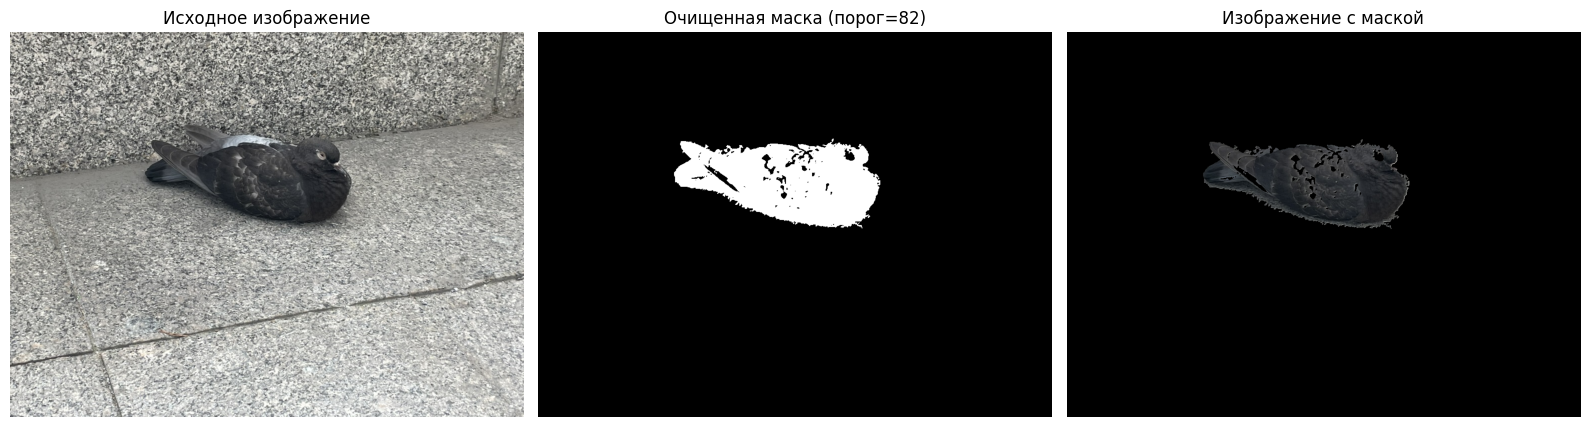

In [ ]:
threshold_value = 82

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
_, mask_visual = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))

mask_visual = cv2.morphologyEx(mask_visual, cv2.MORPH_OPEN, kernel)
mask_visual = cv2.morphologyEx(mask_visual, cv2.MORPH_CLOSE, kernel)
mask_visual = cv2.bitwise_not(mask_visual)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_visual)

min_area = 6_000
clean_mask = np.zeros_like(mask_visual)
for label in range(1, num_labels):
    if stats[label, cv2.CC_STAT_AREA] >= min_area:
        clean_mask[labels == label] = 255

mask_visual = clean_mask
mask = (mask_visual > 0).astype(np.uint8)
masked_image = cv2.bitwise_and(image, image, mask=mask_visual)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Исходное изображение")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mask_visual, cmap="gray")
plt.title(f"Очищенная маска (порог={threshold_value})")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(masked_image)
plt.title("Изображение с маской")
plt.axis("off")
plt.tight_layout()
plt.show()

## Аугментации
Настраиваем пайплайн аугментаций с учётом синхронного преобразования изображения и маски.

In [438]:
transform = Compose([
    HorizontalFlip(p=0.5)
    , VerticalFlip(p=0.3)
    , RandomRotate90(p=0.5)
    , ShiftScaleRotate(
        shift_limit=0.12,
        scale_limit=0.25,
        rotate_limit=40,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0,
        p=0.9
    )
    , OneOf([
        Blur(blur_limit=5, p=1.0)
        , GaussNoise(var_limit=(10.0, 40.0), p=1.0)
    ], p=0.4)
], p=1.0)

examples_to_generate = 100
seen_hashes = set()
for idx in range(1, examples_to_generate + 1):
    attempts = 0
    while True:
        augmented = transform(image=image, mask=mask)
        aug_image = augmented["image"]
        aug_mask = augmented["mask"]
        aug_mask_visual = (aug_mask.astype(np.uint8) * 255)
        combo_hash = hashlib.md5(aug_image.tobytes() + aug_mask_visual.tobytes()).hexdigest()
        if combo_hash not in seen_hashes or attempts >= 5:
            seen_hashes.add(combo_hash)
            break
        attempts += 1
    aug_masked_image = cv2.bitwise_and(aug_image, aug_image, mask=aug_mask_visual)
    cv2.imwrite(str(output_dir / f"aug_mask_{idx:03d}.png"), aug_mask_visual)
    # cv2.imwrite(str(output_dir / f"aug_image_{idx:03d}.png"), cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
    # cv2.imwrite(str(output_dir / f"aug_masked_{idx:03d}.png"), cv2.cvtColor(aug_masked_image, cv2.COLOR_RGB2BGR))
    if idx % 10 == 0 or idx == 1:
        print(f"Сгенерировано {idx} из {examples_to_generate} аугментаций")
print("Готово: все аугментации сохранены в", output_dir)

/var/folders/y7/3khx9vbx74z9_0bd7nswgf080000gn/T/ipykernel_94906/366519925.py:5: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  , ShiftScaleRotate(
/var/folders/y7/3khx9vbx74z9_0bd7nswgf080000gn/T/ipykernel_94906/366519925.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  , GaussNoise(var_limit=(10.0, 40.0), p=1.0)


Сгенерировано 1 из 100 аугментаций
Сгенерировано 10 из 100 аугментаций
Сгенерировано 20 из 100 аугментаций
Сгенерировано 30 из 100 аугментаций
Сгенерировано 20 из 100 аугментаций
Сгенерировано 30 из 100 аугментаций
Сгенерировано 40 из 100 аугментаций
Сгенерировано 50 из 100 аугментаций
Сгенерировано 40 из 100 аугментаций
Сгенерировано 50 из 100 аугментаций
Сгенерировано 60 из 100 аугментаций
Сгенерировано 70 из 100 аугментаций
Сгенерировано 60 из 100 аугментаций
Сгенерировано 70 из 100 аугментаций
Сгенерировано 80 из 100 аугментаций
Сгенерировано 90 из 100 аугментаций
Сгенерировано 80 из 100 аугментаций
Сгенерировано 90 из 100 аугментаций
Сгенерировано 100 из 100 аугментаций
Готово: все аугментации сохранены в output
Сгенерировано 100 из 100 аугментаций
Готово: все аугментации сохранены в output
